In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Cleaned_Transactions_Merged.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,393,2023-01-01 00:00:00,3472.0,Purchase,1.0,Excellent,3
1,2,826,2023-01-01 01:00:00,2460.0,Bill Payment,6.0,Needs improvement,3
2,3,916,2023-01-01 02:00:00,10.0,Purchase,6.0,Needs improvement,3
3,4,109,2023-01-01 03:00:00,72.0,Investment,3.0,Good service,9
4,5,889,2023-01-01 04:00:00,1793.0,Investment,8.0,Very satisfied,3


In [3]:
# Aggregate transaction-level data to customer-level
customer_df = df.groupby("Customer_ID").agg({
    "Transaction_Amount": ["sum", "mean", "count"],
    "Satisfaction_Score": "mean",
    "Likelihood_to_Recommend": "mean"
})

customer_df.columns = [
    "Total_Spend",
    "Avg_Transaction",
    "Transaction_Frequency",
    "Avg_Satisfaction",
    "Avg_Likelihood"
]

customer_df = customer_df.reset_index()

In [4]:
# Create transaction type proportions
transaction_dummies = pd.get_dummies(df["Transaction_Type"])
df_dummies = pd.concat([df[["Customer_ID"]], transaction_dummies], axis=1)

transaction_ratios = df_dummies.groupby("Customer_ID").mean().reset_index()

customer_df = customer_df.merge(transaction_ratios, on="Customer_ID")

In [5]:
features = customer_df.drop("Customer_ID", axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

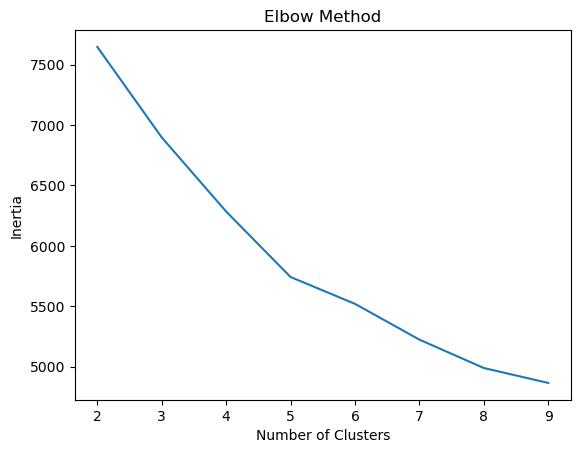

K=2, Silhouette Score=0.133
K=3, Silhouette Score=0.134
K=4, Silhouette Score=0.135
K=5, Silhouette Score=0.141
K=6, Silhouette Score=0.134


In [6]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(2, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    print(f"K={k}, Silhouette Score={score:.3f}")

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

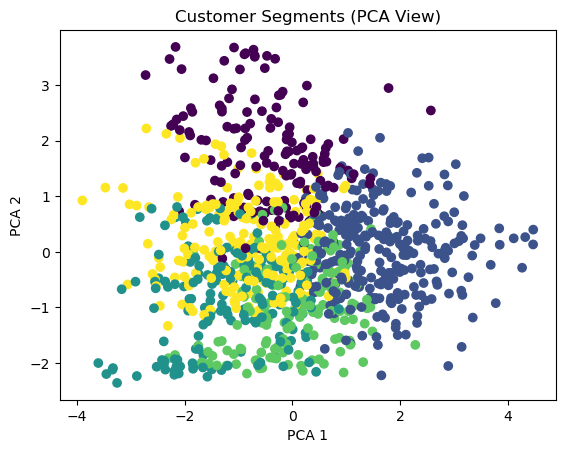

In [11]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure()
plt.scatter(pca_features[:,0], pca_features[:,1], c=customer_df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA View)")
plt.show()

In [12]:
cluster_summary = customer_df.groupby("Cluster").mean()
cluster_summary

,Customer_ID,Total_Spend,Avg_Transaction,Transaction_Frequency,Avg_Satisfaction,Avg_Likelihood,Bill Payment,Investment,Loan Payment,Purchase
Cluster,,,,,,,,,,
0,506.618421,9471.072368,2624.779668,3.717105,5.223684,4.671053,0.606367,0.104057,0.119925,0.169651
1,491.185053,20109.444840,2689.984648,7.580071,5.644128,5.430605,0.273323,0.246809,0.250097,0.229771
2,514.977011,8561.333333,2304.284195,3.781609,4.971264,6.000000,0.144527,0.582225,0.107375,0.165873
3,485.633136,11181.639053,2727.659954,4.213018,5.455621,5.822485,0.115526,0.175486,0.573894,0.135094
4,509.944700,9147.700461,2114.283920,4.308756,6.092166,5.317972,0.141442,0.170639,0.196066,0.491853
